# Stage 3 - NER + keyword extraction

Pulls structured info out of the cleaned comments:
- **Named entities** (people, products, orgs, places) with spaCy - same approach as Lab 2
- **Keywords** - TF-IDF over the whole corpus (Lab 3) plus spaCy noun chunks per comment

This metadata gets attached to each comment and reused by the RAG retriever later.

In: `../data/clean_comments.csv`  Out: `../data/comments_meta.csv`

In [3]:
import pandas as pd
import spacy
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
df = pd.read_csv("../data/clean_comments.csv").dropna(subset=["clean_text"]).reset_index(drop=True)
print(len(df), "comments")
df.head(3)

18771 comments


,comment_id,parent_id,author,published_at,like_count,text,video_id,is_reply,clean_text,lemmas
0,UgzfpT3qlUjjDj_cbb54AaABAg,NaN,@GSMArenaOfficial,2025-03-19T23:01:19Z,8,Our Apple iOS 18.2 review is up now: https://y...,aDqzDoJPkaA,False,our apple is 18.2 review is up now:,apple 18.2 review
1,UgyAYaZ5cKRbmsZePYV4AaABAg,NaN,@cyberlynxplays,2026-04-29T13:14:02Z,0,Is Apple in the red? Because what do you mean ...,aDqzDoJPkaA,False,is apple in the red? because what do you mean ...,apple red mean phone come charge
2,UgysYK9IbV22Ij3EMMh4AaABAg,NaN,@bernardsteele-dadzie7656,2026-04-26T15:29:29Z,0,5years of software support when sansung budget...,aDqzDoJPkaA,False,years of software support when shantung budget...,year software support shantung budget year


## Named Entity Recognition

Using the full model here (we need the `ner` component, unlike stage 2).

In [5]:
nlp = spacy.load("en_core_web_sm")

# keep entity types that actually matter for comment analysis
KEEP = {"PERSON", "ORG", "PRODUCT", "GPE", "LOC", "WORK_OF_ART", "EVENT", "NORP"}

all_ents = []
ent_per_row = []
for doc in nlp.pipe(df["clean_text"].tolist(), batch_size=200):
    ents = [(e.text, e.label_) for e in doc.ents if e.label_ in KEEP]
    ent_per_row.append(", ".join(sorted(set(e[0] for e in ents))))
    all_ents.extend(ents)

df["entities"] = ent_per_row
print("found", len(all_ents), "entity mentions")

found 7006 entity mentions


In [6]:
# what are people actually talking about?
top_people = Counter(t for t, lbl in all_ents if lbl == "PERSON").most_common(15)
top_orgs   = Counter(t for t, lbl in all_ents if lbl in ("ORG", "PRODUCT")).most_common(15)
top_places = Counter(t for t, lbl in all_ents if lbl in ("GPE", "LOC")).most_common(15)

print("PEOPLE  :", top_people)
print("ORG/PROD:", top_orgs)
print("PLACES  :", top_places)

PEOPLE  : [('max', 438), ('Sick Iss', 332), ('anna', 171), ('samson', 41), ('Artificial Intelligence', 39), ('lava', 28), ('gb', 23), ('anna phone', 22), ('Key', 21), ('Instant Message', 19), ('Donna Lie', 17), ('anna am', 15), ('doesn', 14), ('rah hello', 14), ('ofा', 11)]
ORG/PROD: [('apple', 150), ('Artificial Intelligence', 112), ('Sick Iss', 68), ('motorola', 55), ('samson', 50), ('samson s', 28), ('un', 25), ('على', 20), ('ايه', 18), ('the Artificial Intelligence', 17), ('Parents Are', 16), ('،', 13), ('ip16', 10), ('ngayon', 10), ('أنا', 10)]
PLACES  : [('india', 61), ('havana', 39), ('china', 33), ('n’t', 29), ('panama', 27), ('sonya', 20), ('nile', 19), ('Sick Iss', 19), ('bhaiya', 17), ('us', 11), ('japan', 11), ('kansas', 9), ('canada', 9), ('brow', 8), ('rome', 8)]


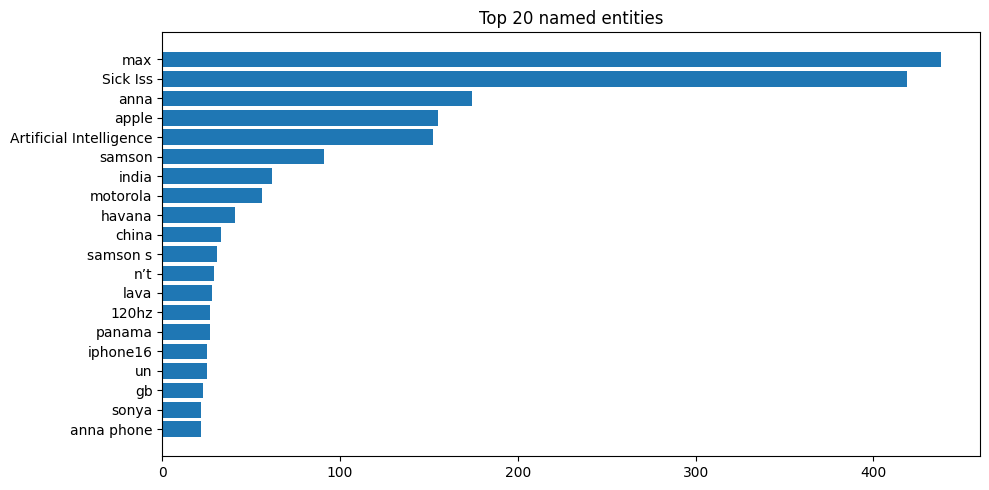

In [7]:
# quick bar chart of the top entities overall
import matplotlib.pyplot as plt
top = Counter(t for t, lbl in all_ents).most_common(20)
labels = [t for t, n in top]
counts = [n for t, n in top]
plt.figure(figsize=(10, 5))
plt.barh(labels[::-1], counts[::-1])
plt.title("Top 20 named entities")
plt.tight_layout()
plt.show()

## Keyword extraction (TF-IDF)

Top terms across the corpus, computed on the lemmas column from stage 2.

In [8]:
corpus = df["lemmas"].fillna("").tolist()

tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=5)
X = tfidf.fit_transform(corpus)

# overall importance = mean tfidf per term
import numpy as np
scores = np.asarray(X.mean(axis=0)).ravel()
terms = tfidf.get_feature_names_out()
top_kw = sorted(zip(terms, scores), key=lambda x: x[1], reverse=True)[:30]
for t, s in top_kw:
    print(f"{t:25s} {s:.4f}")

phone                     0.0608
brother                   0.0256
of                        0.0241
professional              0.0200
like                      0.0172
video                     0.0166
anna                      0.0150
hello                     0.0149
good                      0.0138
camera                    0.0130
apple                     0.0129
watch                     0.0121
samson                    0.0120
review                    0.0119
of of                     0.0110
well                      0.0108
buy                       0.0104
plus                      0.0101
get                       0.0099
new                       0.0098
love                      0.0091
max                       0.0088
god                       0.0081
year                      0.0080
60hz                      0.0078
thank                     0.0078
professional max          0.0077
look                      0.0076
motor                     0.0072
nice                      0.0070


In [9]:
# per-comment keywords = its highest tfidf terms (handy for the retriever metadata later)
feature_names = tfidf.get_feature_names_out()
def row_keywords(i, k=5):
    row = X[i].toarray().ravel()
    idx = row.argsort()[::-1][:k]
    return ", ".join(feature_names[j] for j in idx if row[j] > 0)

df["keywords"] = [row_keywords(i) for i in range(X.shape[0])]
df[["clean_text", "entities", "keywords"]].head(8)

,clean_text,entities,keywords
0,our apple is 18.2 review is up now:,,"18, review, apple"
1,is apple in the red? because what do you mean ...,,"mean phone, phone come, red, mean, charge"
2,years of software support when shantung budget...,shantung,"year, software, support, budget"
3,can someone please buy me phone please,,"buy phone, buy, phone"
4,this is such a Parent Over Shoulder. everytime...,,"near, pick, feel like, find, parent"
5,i’m upbraiding my phone is plus to phone 16 ne...,,"excited, plus phone, upbraid phone, week, upbraid"
6,i want to upgrade my 12 to a 16 because i’m co...,,"storage, want upgrade, completely, need, want"
7,@s@shib88 is good. big upgrade for me,,"big upgrade, big, upgrade, good"


In [10]:
df.to_csv("../data/comments_meta.csv", index=False)
print("saved ->", "../data/comments_meta.csv")

saved -> ../data/comments_meta.csv
